In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [2]:
path_c = '../../../combined_cannonical.tab'
path_ncind = '../../../combined_nc-ind.tab'
path_ncl = '../../../combined_nc-Leader.tab'
canonical = pd.read_csv(path_c, sep = "\t")
nc_leader = pd.read_csv(path_ncl, sep = "\t")
nc_ind = pd.read_csv(path_ncind, sep = "\t")

In [3]:
canon_artic = canonical[canonical['Source_File'].str.contains('artic_primer')]
canon_artic.head()
nc_leader_artic = nc_leader[nc_leader['Source_File'].str.contains('artic_primer')]
#nc_leader_artic.head()

In [4]:
canon_artic[['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = canon_artic["cluster_normalized_count"].str.extract('(.+)\\((.+),(.+),(.+),(.+)\\)')

In [5]:
mapping_samples = {"SRR23438390": "6268_2_96h", "SRR23438391": "6268_1_96h", "SRR23438392": "6267_2_72h", "SRR23438393": "6267_1_72h",\
                   "SRR23438394": "6266_2_48h", "SRR23438395": "6266_1_48h", "SRR23438396": "6265_2_24h", "SRR23438397": "6265_1_24h",\
                   "SRR23438398": "6264_2_T0", "SRR23438399": "6264_1_T0"}

benchmarking_data = pd.read_csv("../../../benchmarking_paper_letrs_res.csv")
benchmarking_comp = canonical[canonical['Source_File'].str.contains('PRJNA934289')]
benchmarking_comp['sample'] = benchmarking_comp['Source_File'].str.slice(-11).map(mapping_samples)
benchmarking_comp[['c_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one']] = benchmarking_comp["cluster_count"].str.extract('(.+)\\((.+),(.+),(.+),(.+)\\)')
benchmarking_comp['c_ct'] = benchmarking_comp['c_ct'].fillna(0)
benchmarking_data = benchmarking_data.merge(benchmarking_comp, on = ["subgenome", "sample"], how = "right")
benchmarking_data = pd.melt(benchmarking_data, id_vars = ['subgenome', 'sample'], value_vars = ['bm_count', 'c_ct'], var_name = 'run', value_name = 'count')
benchmarking_data['run'] = benchmarking_data['run'].map({"bm_count": "Paper", "c_ct": "In-House"})
benchmarking_data['count'] = pd.to_numeric(benchmarking_data['count'])
benchmarking_data.head(10)

,subgenome,sample,run,count
0,S,6265_2_24h,Paper,589
1,ORF3a,6265_2_24h,Paper,9
2,E,6265_2_24h,Paper,62
3,M,6265_2_24h,Paper,1099
4,ORF6,6265_2_24h,Paper,303
5,ORF7a,6265_2_24h,Paper,43
6,ORF7b,6265_2_24h,Paper,0
7,ORF8,6265_2_24h,Paper,2
8,N,6265_2_24h,Paper,2456
9,ORF10,6265_2_24h,Paper,0


c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


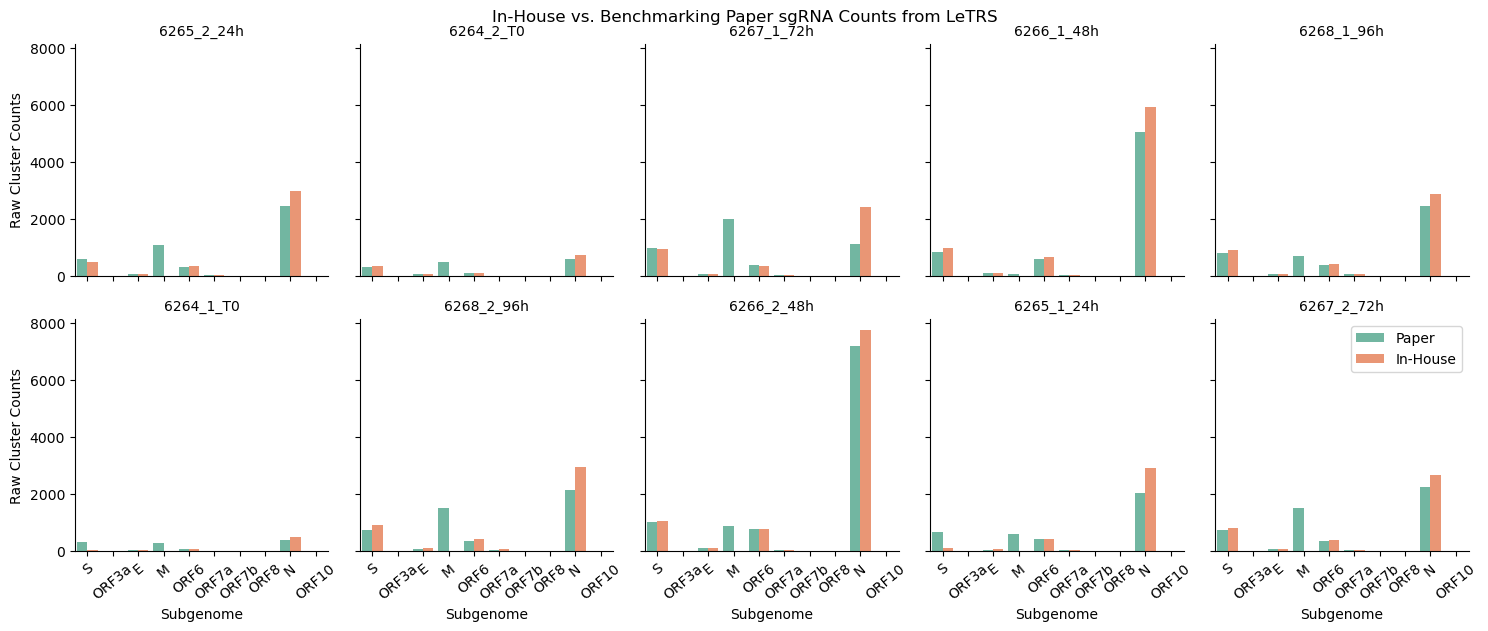

In [6]:
grid = sns.FacetGrid(benchmarking_data, col="sample", col_wrap=5)
grid.map(sns.barplot, "subgenome", "count", data = benchmarking_data, hue = "run", palette = "Set2")
grid.set_titles("{col_name}")
grid.set_xlabels("Subgenome")
grid.set_xticklabels(["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"], rotation=40)
grid.set_ylabels("Raw Cluster Counts")
plt.suptitle("In-House vs. Benchmarking Paper sgRNA Counts from LeTRS", y=1)
plt.legend()
plt.show()

c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


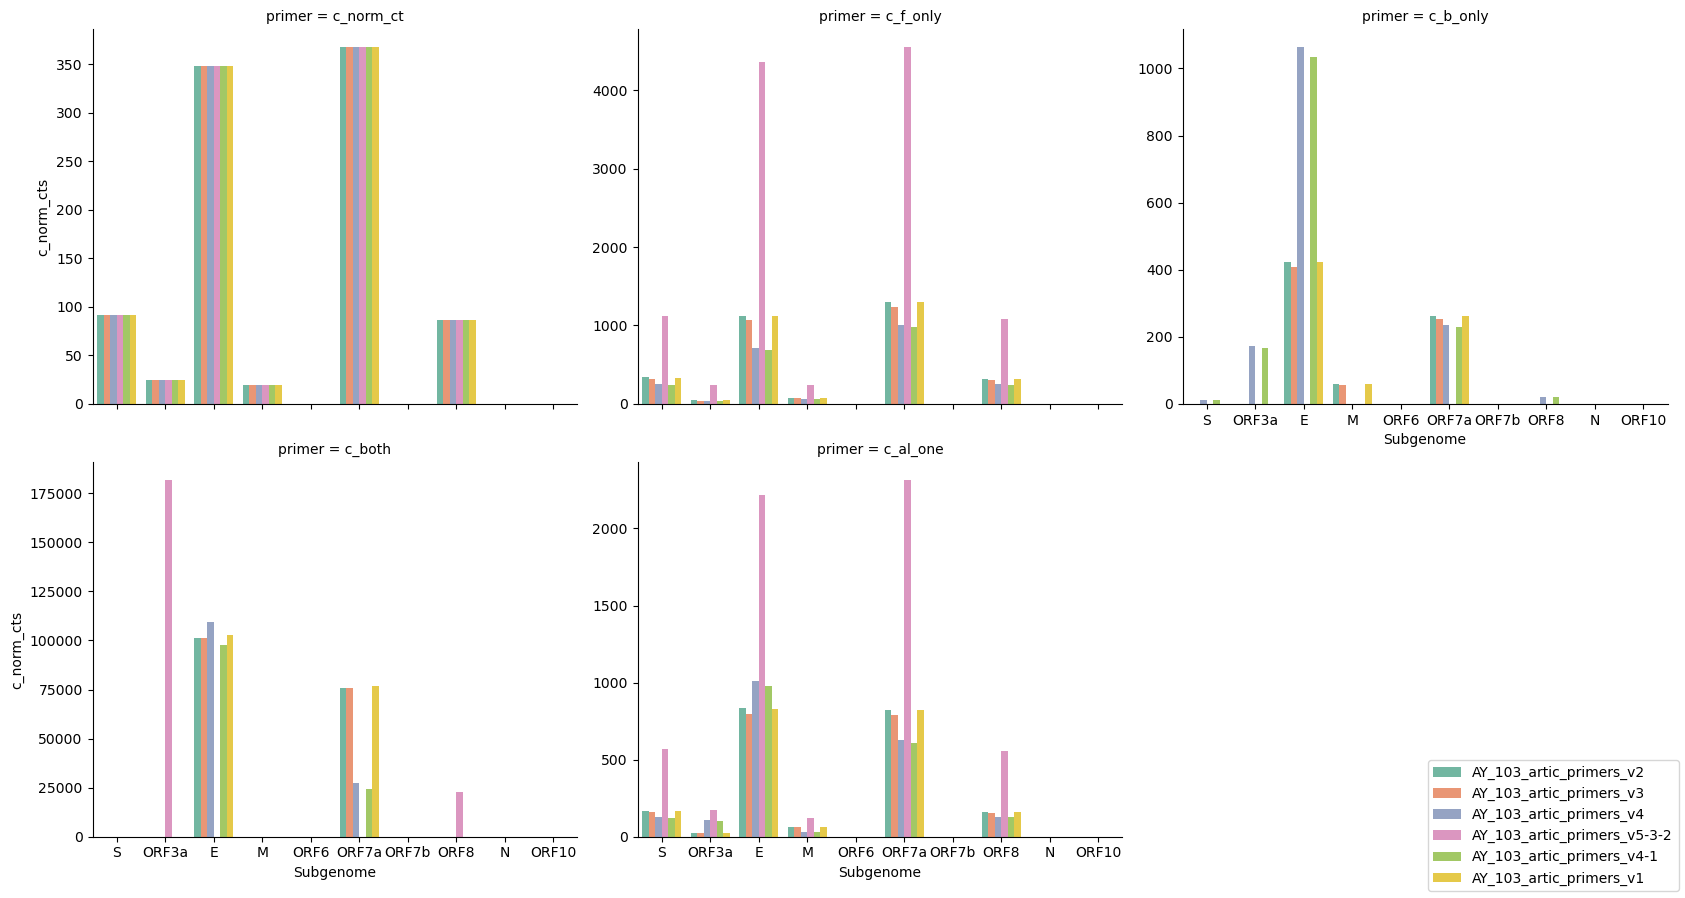

In [7]:
# Visualizing for beta
vis_data = pd.melt(canon_artic[canon_artic['Source_File'].str.contains('AY_103')], id_vars = ['Source_File', 'subgenome'],\
                   value_vars = ['c_norm_ct', 'c_f_only', 'c_b_only', 'c_both', 'c_al_one'], var_name = 'primer',
                   value_name = 'c_norm_cts')

vis_data['c_norm_cts'] = vis_data['c_norm_cts'].astype(float)

grid = sns.FacetGrid(vis_data, col="primer", col_wrap=3, height = 4.5, aspect =1.25, sharey=False, legend_out=False)
grid.map(sns.barplot, "subgenome", "c_norm_cts", data = vis_data, hue = 'Source_File', palette = 'Set2')
grid.set_xlabels("Subgenome")
grid.add_legend()
sns.move_legend(grid, "lower right")
plt.show()


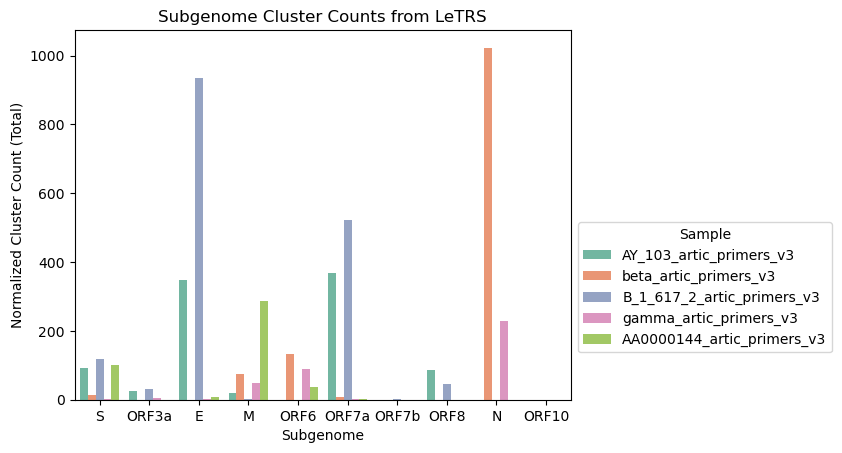

In [8]:
vis_data2 = canon_artic[canon_artic['Source_File'].str.contains('v3')]

vis_data2['c_norm_ct'] = vis_data2['c_norm_ct'].astype(float)

sns.barplot(data = vis_data2, x = 'subgenome', y = 'c_norm_ct', hue = 'Source_File', palette = 'Set2')
plt.xlabel("Subgenome")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Sample", bbox_to_anchor=(1, 0.5))
plt.show()

In [9]:
exclude = ["Sim_Data_FA_primer", "AA0000114", "AY_103_artic_primers_v1", "AY_103_artic_primers_v2", "AY_103_artic_primers_v4",\
           "AY_103_artic_primers_v4-1", "AY_103_artic_primers_v5-3-2", "B_1_617_2_artic_primers_v1", "B_1_617_2_artic_primers_v2",\
           "B_1_617_2_artic_primers_v4", "B_1_617_2_artic_primers_v4_1", "B_1_617_2_artic_primers_v5_3_2", "OG_Paper", "Simulated_Data_With_FA",\
            "beta_artic_primers_v1", "beta_artic_primers_v2", "beta_artic_primers_v4", "beta_artic_primers_v4-1", "beta_artic_primers_v5-3-2",\
            "gamma_artic_primers_v1", "gamma_artic_primers_v2", "gamma_artic_primers_v4", "gamma_artic_primers_v4-1", "gamma_artic_primers_v5-3-2",\
            "PRJNA1193019_Fasta", "ART_Nanopore_mode", "Sim_NCsgRNA", "Sim_Data_FA_articv3", "AA0000144_artic_primers_v1", "AA0000144_artic_primers_v2",\
            "AA0000144_artic_primers_v4", "AA0000144_artic_primers_v4-1", "AA0000144_artic_primers_v5-3-2", "Simulated_Data", "SD_ART", "AY_103_NC_cutoff_1",\
            "WT_Covid", "alpha-00148_alpha_ref", "alpha-00149_alpha_ref", "alpha-00150_alpha_ref"]
canon_strains = canonical[~canonical['Source_File'].isin(exclude)]
alpha_comp = canonical[canonical['Source_File'].str.contains('alpha')]
canon_strains.loc[:,'Strain'] = canonical['Source_File'].case_when([(canonical['Source_File'].str.contains('omicron|ba_2'), 'Omicron'),\
                                                            (canonical['Source_File'].str.contains('beta'), 'Beta'),\
                                                            (canonical['Source_File'].str.contains('gamma'), 'Gamma'),\
                                                            (canonical['Source_File'].str.contains('delta|AY_103|B_1_617'), 'Delta'),
                                                            (canonical['Source_File'].str.contains('AA0000144|alpha'), 'Alpha'),\
                                                            (canonical['Source_File'].str.contains('b_1-0'), 'Wild Type'),\
                                                            (canonical['Source_File'].str.contains('PRJNA1193019'), 'Persistent Infection')])
canon_strains.loc[:,'c_norm_ct'] = canon_strains.loc[:,"cluster_normalized_count"].str.extract('(.+)\\(').astype(float)
canon_strains.loc[:,'c_ct'] = canon_strains.loc[:,"cluster_count"].str.extract('(.+)\\(').astype(float)
canon_strains = canon_strains.fillna(0)
canon_strains.head()
canon_strains.to_csv('./LeTRS_canonical_strain_res.csv', index = False)

In [10]:
alpha_comp.loc[:,'Reference'] = alpha_comp['Source_File'].case_when([(canonical['Source_File'].str.contains('ref'), 'Alpha'),\
                                                            (~canonical['Source_File'].str.contains('ref'), 'WT')])
alpha_comp.loc[:,'c_norm_ct'] = alpha_comp.loc[:,"cluster_normalized_count"].str.extract('(.+)\\(').astype(float).fillna(0)
alpha_comp.loc[:,'sample'] = alpha_comp.loc[:,"Source_File"].str.extract('(?<=alpha-)(.+?)(?=_alpha|$)').astype(float)

alpha_comp.head()


,subgenome,ref_leader_end,peak_leader_end,ref_TRS_start,peak_TRS_start,peak_count,peak_normalized_count,cluster_count,cluster_normalized_count,Source_File,Reference,c_norm_ct,sample
220,S,65,72,21552,21538,"1(0,0,0,0)","0.67(0.00,0.00,0.00,0.00)","1(0,0,0,0)","0.67(0.00,0.00,0.00,0.00)",alpha-00149_alpha_ref,Alpha,0.67,149.0
221,ORF3a,69,0,25385,0,0,0,0,0,alpha-00149_alpha_ref,Alpha,0.00,149.0
222,E,69,0,26237,0,0,0,0,0,alpha-00149_alpha_ref,Alpha,0.00,149.0
223,M,65,0,26469,0,0,0,0,0,alpha-00149_alpha_ref,Alpha,0.00,149.0
224,ORF6,69,69,27041,27023,"1(0,0,0,0)","0.67(0.00,0.00,0.00,0.00)","2(0,0,0,0)","1.34(0.00,0.00,0.00,0.00)",alpha-00149_alpha_ref,Alpha,1.34,149.0


c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


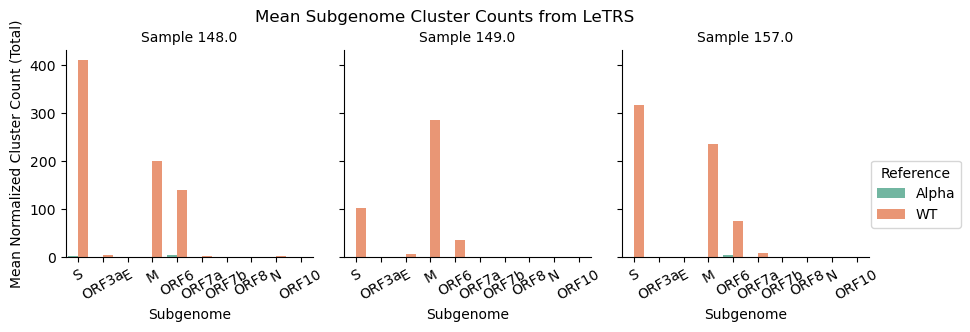

In [11]:
grid = sns.FacetGrid(data = alpha_comp, col = 'sample', legend_out=True)
grid.map(sns.barplot, 'subgenome', 'c_norm_ct', data = alpha_comp, hue = 'Reference', palette = 'Set2')
grid.set_xlabels("Subgenome")
grid.set_xticklabels(rotation=30)
grid.set_ylabels("Mean Normalized Cluster Count (Total)")
grid.set_titles("Sample {col_name}")
plt.suptitle("Mean Subgenome Cluster Counts from LeTRS", y=1.02)
plt.legend(title = "Reference", bbox_to_anchor=(1.4, 0.5))
plt.show()


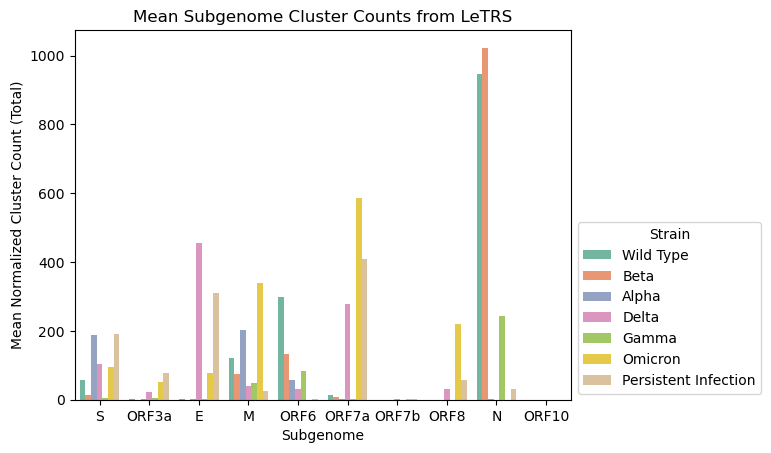

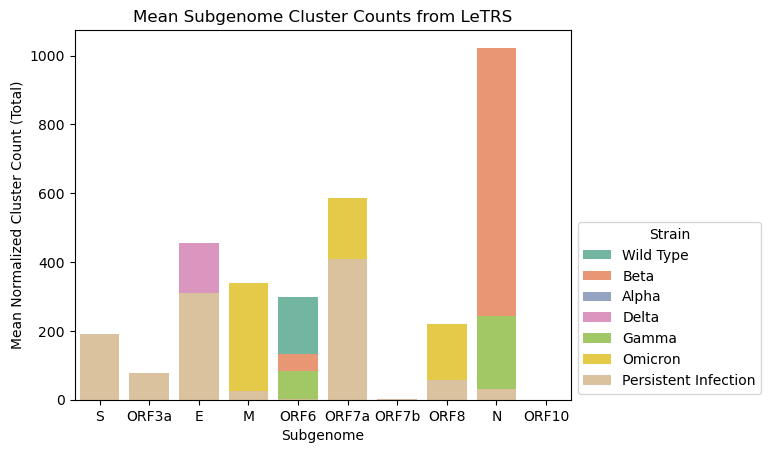

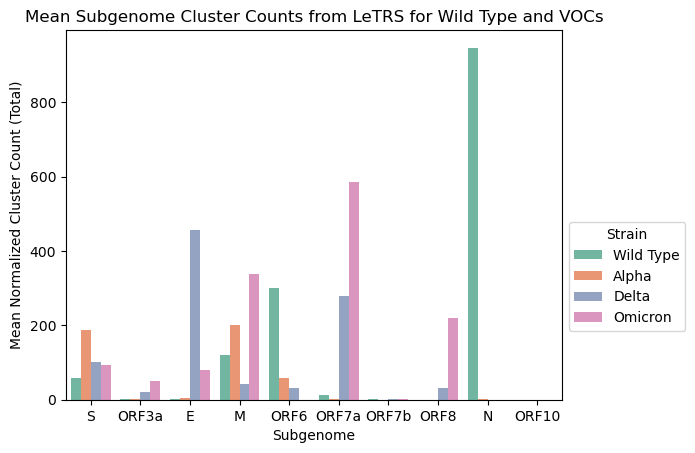

In [12]:
sns.barplot(data = canon_strains, x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"])
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

sns.barplot(data = canon_strains, x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"], \
                dodge = False)
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

sns.barplot(data = canon_strains[canon_strains['Strain'].isin(['Wild Type', 'Alpha', 'Delta', 'Omicron'])], x = 'subgenome', y = 'c_norm_ct', hue = 'Strain', palette = 'Set2', \
            errorbar = None, hue_order = ['Wild Type', 'Alpha', 'Delta', 'Omicron'])
plt.xlabel("Subgenome")
plt.ylabel("Mean Normalized Cluster Count (Total)")
plt.title("Mean Subgenome Cluster Counts from LeTRS for Wild Type and VOCs")
plt.legend(title = "Strain", bbox_to_anchor=(1, 0.5))
plt.show()

c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


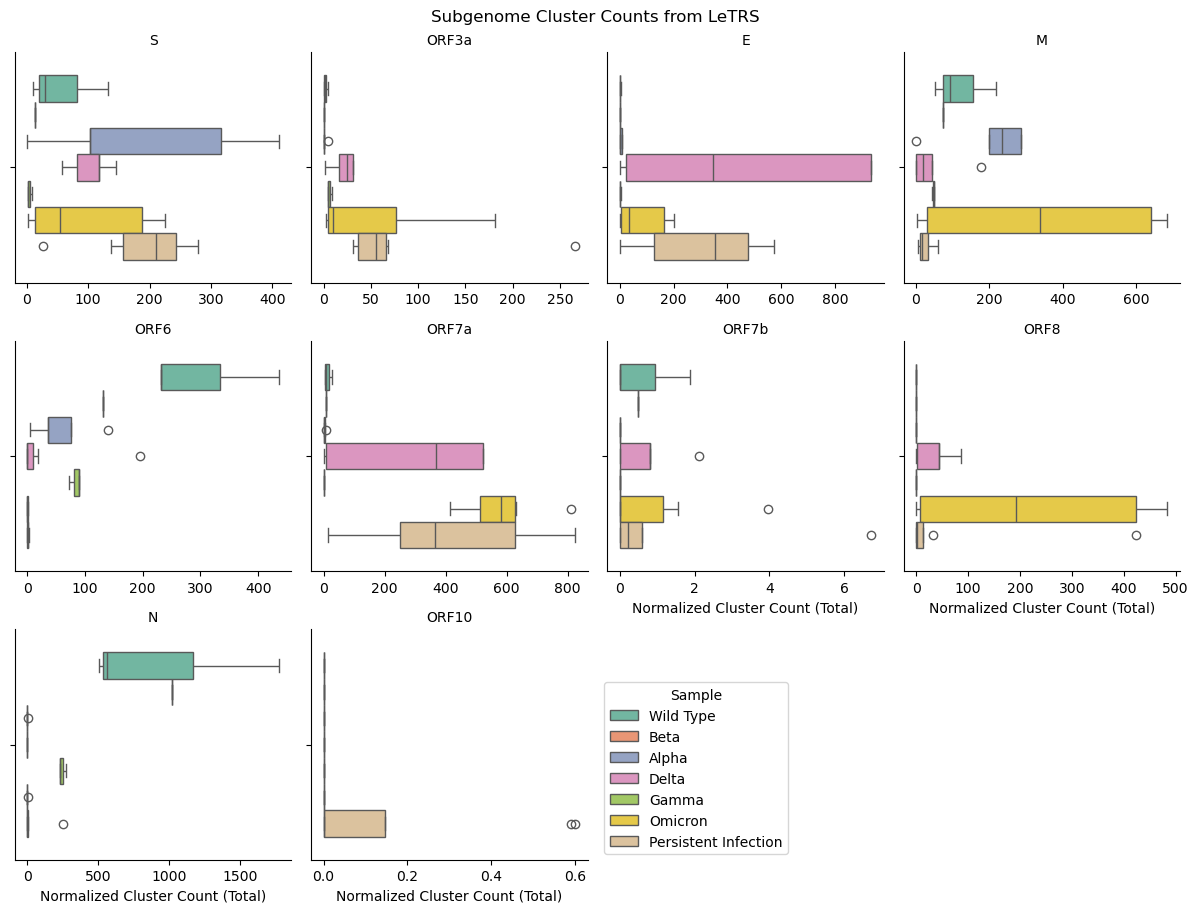

In [13]:
grid = sns.FacetGrid(canon_strains, col="subgenome", col_wrap = 4, sharex=False, legend_out=True)
grid.map(sns.boxplot, 'c_norm_ct', data = canon_strains, hue = 'Strain', palette = 'Set2', hue_order = ["Wild Type", "Beta", "Alpha", "Delta", "Gamma", "Omicron", "Persistent Infection"])
grid.set_xlabels("Subgenome")
grid.set_xlabels("Normalized Cluster Count (Total)")
grid.set_titles("{col_name}")
plt.suptitle("Subgenome Cluster Counts from LeTRS", y=1.01)
plt.legend(title = "Sample", bbox_to_anchor=(1.75, 0.8))
plt.show()

In [14]:
PI_data = canon_strains[canon_strains['Strain'] == 'Persistent Infection']
PI_data["Timepoint"] = PI_data['Source_File'].case_when([(PI_data['Source_File'].str.contains('SRR31567433'), 776),
                                                        (PI_data['Source_File'].str.contains('SRR31567434'), 776), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567435'), 640),
                                                        (PI_data['Source_File'].str.contains('SRR31567436'), 630),
                                                        (PI_data['Source_File'].str.contains('SRR31567437'), 630), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567438'), 522),
                                                        (PI_data['Source_File'].str.contains('SRR31567439'), 401),
                                                        (PI_data['Source_File'].str.contains('SRR31567440'), 312)])
PI_data['c_norm_ct'] = PI_data['c_norm_ct'].fillna(0)
PI_no_throat = PI_data[~PI_data['Source_File'].str.contains('SRR31567434|SRR31567437')]
PI_data.head()

,subgenome,ref_leader_end,peak_leader_end,ref_TRS_start,peak_TRS_start,peak_count,peak_normalized_count,cluster_count,cluster_normalized_count,Source_File,Strain,c_norm_ct,c_ct,Timepoint
140,S,65,65,21552,21552,"460(68,7,0,75)","271.53(522.00,49.92,0.00,275.91)","473(69,8,0,77)","279.21(529.68,57.05,0.00,283.26)",PRJNA1193019_SRR31567439,Persistent Infection,279.21,473.0,401
141,ORF3a,69,69,25385,25385,"108(11,27,1,39)","63.75(84.44,192.55,746.83,143.47)","110(11,27,1,39)","64.93(84.44,192.55,746.83,143.47)",PRJNA1193019_SRR31567439,Persistent Infection,64.93,110.0,401
142,E,69,69,26237,26237,"777(103,178,34,315)","458.65(790.68,1269.39,25392.08,1158.80)","777(103,178,34,315)","458.65(790.68,1269.39,25392.08,1158.80)",PRJNA1193019_SRR31567439,Persistent Infection,458.65,777.0,401
143,M,65,65,26469,26469,"6(0,0,0,0)","3.54(0.00,0.00,0.00,0.00)","8(1,0,0,1)","4.72(7.68,0.00,0.00,3.68)",PRJNA1193019_SRR31567439,Persistent Infection,4.72,8.0,401
144,ORF6,69,69,27041,27041,"4(0,1,0,1)","2.36(0.00,7.13,0.00,3.68)","4(0,1,0,1)","2.36(0.00,7.13,0.00,3.68)",PRJNA1193019_SRR31567439,Persistent Infection,2.36,4.0,401


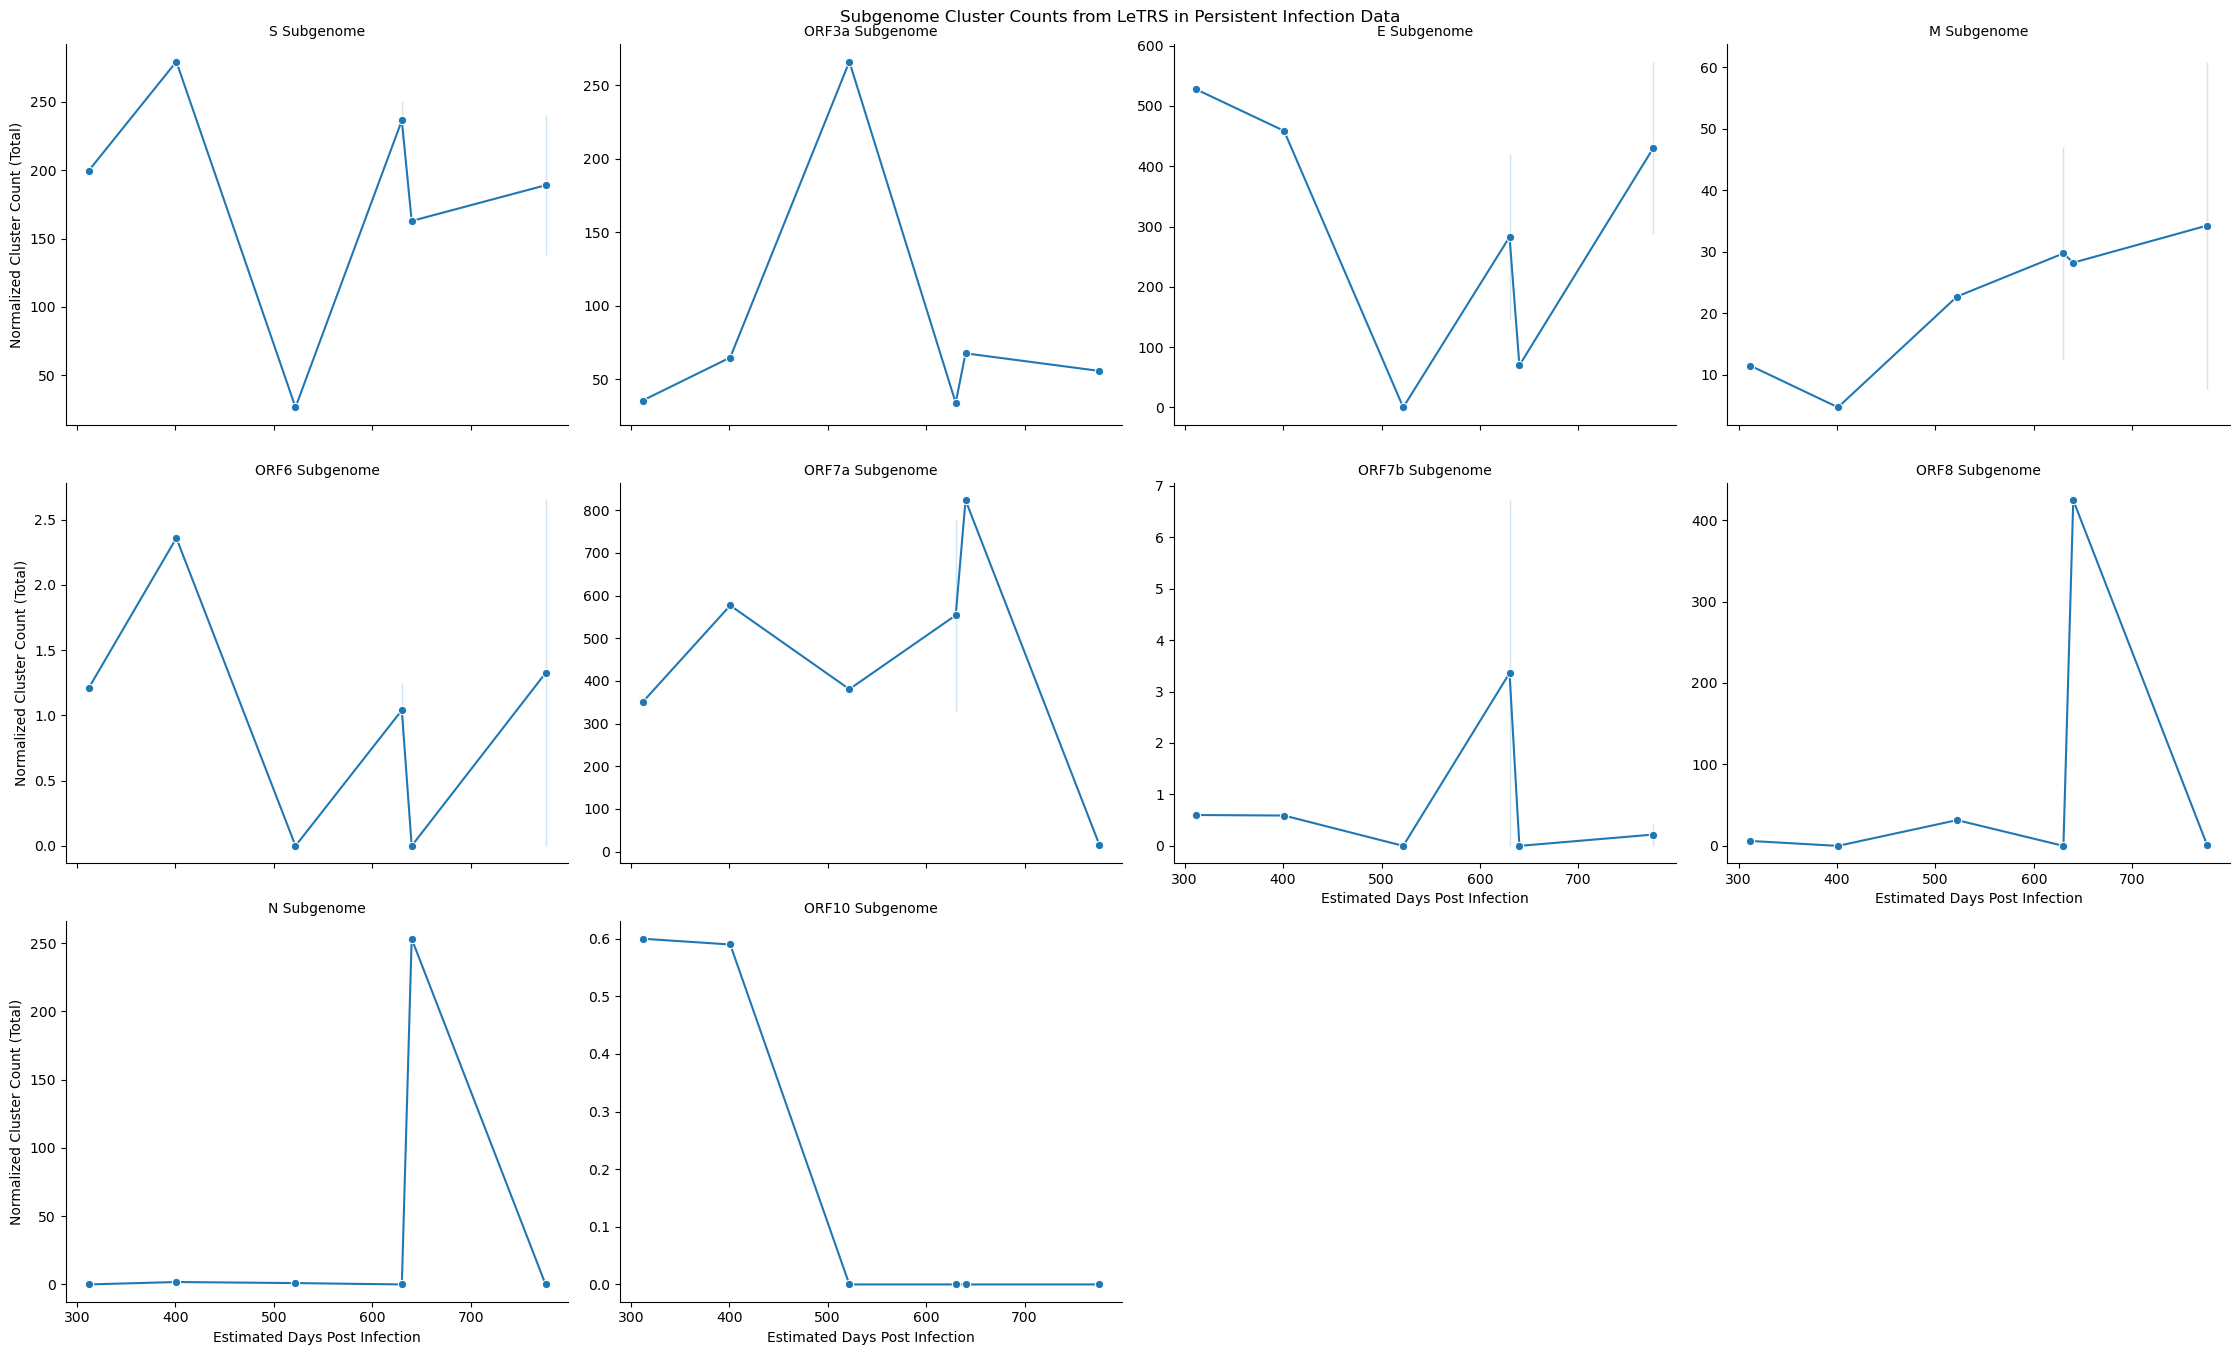

In [15]:
grid = sns.FacetGrid(PI_data, col="subgenome", height = 4.5, aspect =1.25, sharey=False, legend_out=True, col_wrap = 4)
grid.map(sns.lineplot, 'Timepoint', 'c_norm_ct', data = PI_no_throat, marker = 'o')
grid.set_xlabels("Estimated Days Post Infection")
grid.set_ylabels("Normalized Cluster Count (Total)")
grid.set_titles(col_template = "{col_name} Subgenome")
plt.suptitle("Subgenome Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.show()

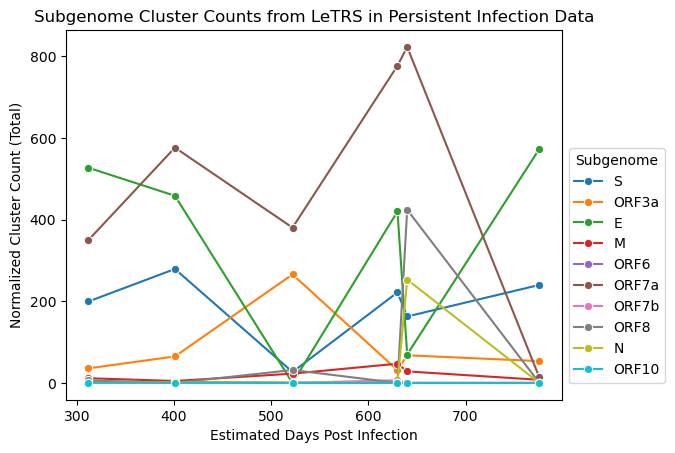

In [16]:
sns.lineplot(x = 'Timepoint', y ='c_norm_ct', data = PI_no_throat, hue = "subgenome", marker = 'o', \
             hue_order = ["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"])
plt.xlabel("Estimated Days Post Infection")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("Subgenome Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.legend(title = "Subgenome", bbox_to_anchor=(1, 0.7))
plt.show()

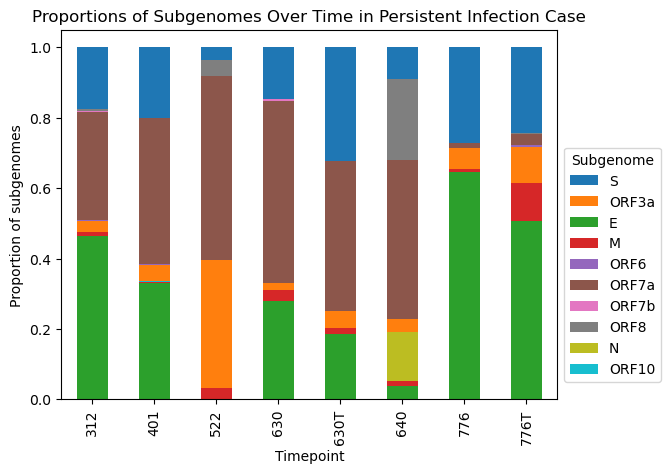

In [17]:
PI_throat_label = PI_data.copy()
PI_throat_label["Timepoint"] = PI_throat_label['Source_File'].case_when([(PI_data['Source_File'].str.contains('SRR31567433'), "776"),
                                                        (PI_data['Source_File'].str.contains('SRR31567434'), "776T"), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567435'), "640"),
                                                        (PI_data['Source_File'].str.contains('SRR31567436'), "630"),
                                                        (PI_data['Source_File'].str.contains('SRR31567437'), "630T"), # Throat swab
                                                        (PI_data['Source_File'].str.contains('SRR31567438'), "522"),
                                                        (PI_data['Source_File'].str.contains('SRR31567439'), "401"),
                                                        (PI_data['Source_File'].str.contains('SRR31567440'), "312")])
prop_plot_data = PI_throat_label.copy()
#prop_plot_data.groupby(['Timepoint'])['subgenome'].value_counts(normalize = True).unstack('subgenome').plot.bar(stacked=True)
prop_plot_data = (PI_throat_label.groupby(['Timepoint','subgenome'])['c_norm_ct'].sum()/PI_throat_label.groupby(['Timepoint'])['c_norm_ct'].sum())
#prop_plot_data['proportions'] = prop_plot_data['c_norm_ct'] / prop_plot_data.groupby(['Timepoint'])['c_norm_ct'].transform('sum')
color_dict = {}
orfs = ["S", "ORF3a", "E", "M", "ORF6", "ORF7a", "ORF7b", "ORF8", "N", "ORF10"]
for o in range(len(orfs)):
    color_dict[orfs[o]] = sns.color_palette()[o]
prop_plot_data.unstack().plot.bar(color = color_dict, stacked=True)
idx = [9, 4, 0, 1, 5, 6, 7, 8, 2, 3]
handles, labels = plt.gca().get_legend_handles_labels()
reord_labels = [labels[i] for i in idx]
reord_handles = [handles[i] for i in idx]
plt.title('Proportions of Subgenomes Over Time in Persistent Infection Case')
plt.ylabel('Proportion of subgenomes')
plt.xlabel('Timepoint')
plt.legend(title = 'Subgenome', bbox_to_anchor=(1, 0.7), labels = reord_labels, handles = reord_handles)
plt.show()


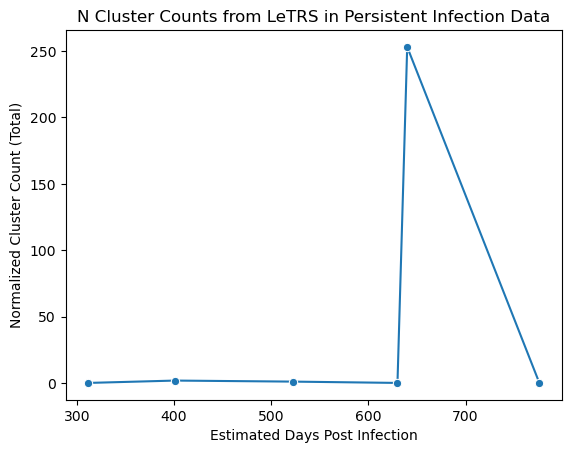

In [18]:
sns.lineplot(x = 'Timepoint', y ='c_norm_ct', data = PI_no_throat[PI_no_throat['subgenome']=='N'], marker = 'o')
plt.xlabel("Estimated Days Post Infection")
plt.ylabel("Normalized Cluster Count (Total)")
plt.title("N Cluster Counts from LeTRS in Persistent Infection Data", y=1)
plt.show()

c:\Users\exmar\miniconda\envs\challnge_proj\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


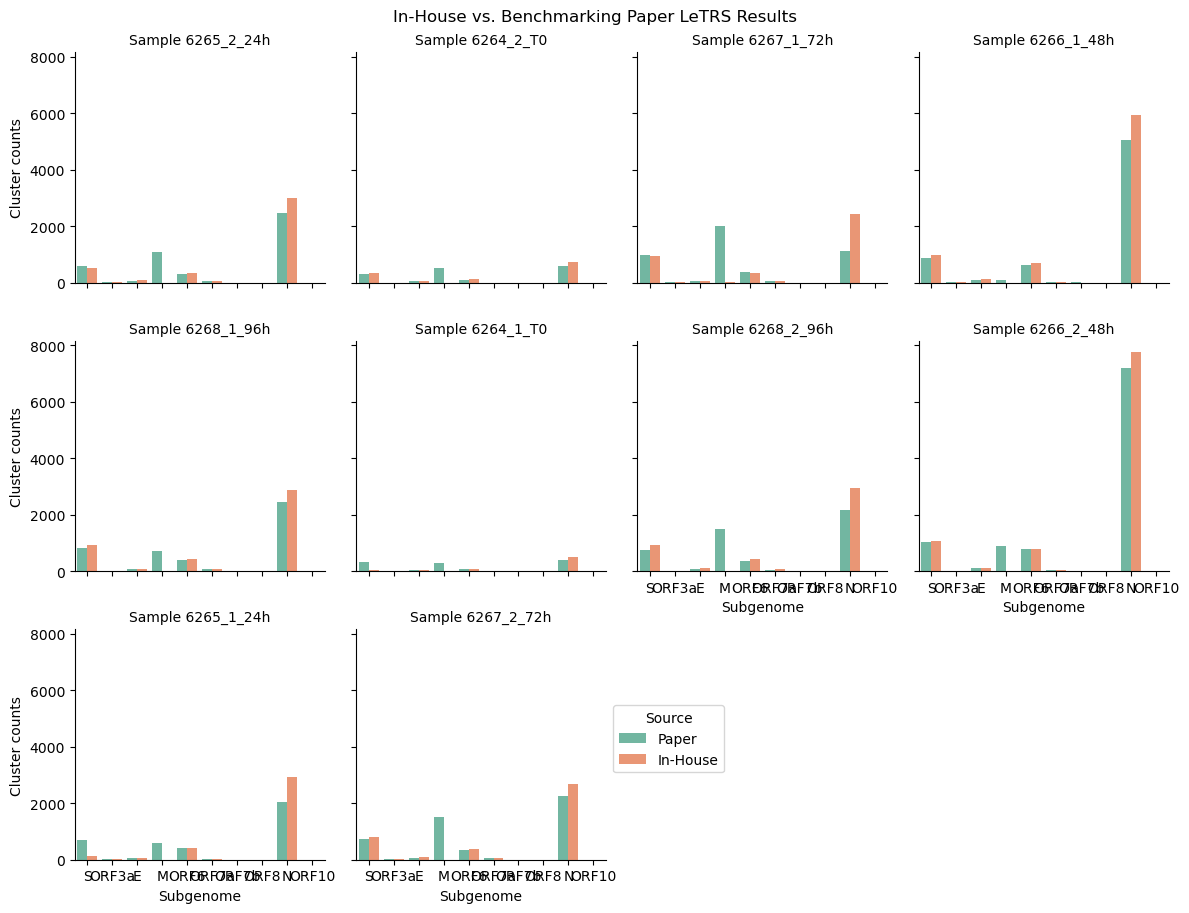

In [19]:
grid = sns.FacetGrid(benchmarking_data, col = 'sample', col_wrap = 4, legend_out = True)
grid.map(sns.barplot, 'subgenome', 'count', data = benchmarking_data, hue = 'run', palette = "Set2")
grid.set_xlabels('Subgenome')
grid.set_ylabels('Cluster counts')
grid.set_titles('Sample {col_name}')
#grid.set_xticklabels(rotation=30)
plt.legend(title = "Source", bbox_to_anchor=(1.5, 0.7))
plt.suptitle("In-House vs. Benchmarking Paper LeTRS Results", y=1.01)
plt.show()

In [20]:
exclude = ["Sim_Data_FA_primer", "AA0000114", "AY_103_artic_primers_v1", "AY_103_artic_primers_v2", "AY_103_artic_primers_v4",\
           "AY_103_artic_primers_v4-1", "AY_103_artic_primers_v5-3-2", "B_1_617_2_artic_primers_v1", "B_1_617_2_artic_primers_v2",\
           "B_1_617_2_artic_primers_v4", "B_1_617_2_artic_primers_v4_1", "B_1_617_2_artic_primers_v5_3_2", "OG_Paper", "Simulated_Data_With_FA",\
            "beta_artic_primers_v1", "beta_artic_primers_v2", "beta_artic_primers_v4", "beta_artic_primers_v4-1", "beta_artic_primers_v5-3-2",\
            "gamma_artic_primers_v1", "gamma_artic_primers_v2", "gamma_artic_primers_v4", "gamma_artic_primers_v4-1", "gamma_artic_primers_v5-3-2",\
            "PRJNA1193019_Fasta", "ART_Nanopore_mode", "Sim_NCsgRNA", "Sim_Data_FA_articv3", "AA0000144_artic_primers_v1", "AA0000144_artic_primers_v2",\
            "AA0000144_artic_primers_v4", "AA0000144_artic_primers_v4-1", "AA0000144_artic_primers_v5-3-2", "Simulated_Data", "SD_ART", "AY_103_NC_cutoff_1",\
            "WT_Covid", "alpha-00148_alpha_ref", "alpha-00149_alpha_ref", "alpha-00150_alpha_ref"]
nc_leader_strains = nc_leader[~nc_leader['Source_File'].isin(exclude)]
alpha_comp = nc_leader[nc_leader['Source_File'].str.contains('alpha')]
nc_leader_strains.loc[:,'Strain'] = nc_leader['Source_File'].case_when([(nc_leader['Source_File'].str.contains('omicron|ba_2'), 'Omicron'),\
                                                            (nc_leader['Source_File'].str.contains('beta'), 'Beta'),\
                                                            (nc_leader['Source_File'].str.contains('gamma'), 'Gamma'),\
                                                            (nc_leader['Source_File'].str.contains('delta|AY_103|B_1_617'), 'Delta'),
                                                            (nc_leader['Source_File'].str.contains('AA0000144|alpha'), 'Alpha'),\
                                                            (nc_leader['Source_File'].str.contains('b_1-0'), 'Wuhan'),\
                                                            (nc_leader['Source_File'].str.contains('PRJNA1193019'), 'Persistent Infection')])
nc_leader_strains.loc[:,'norm_ct'] = nc_leader_strains.loc[:,"normalized_count"].str.extract('(.+)\\(').astype(float)
#nc_leader_strains.loc[:,'c_ct'] = nc_leader_strains.loc[:,"cluster_count"].str.extract('(.+)\\(').astype(float)
nc_leader_strains = nc_leader_strains.fillna(0)
nc_leader_strains.head()
nc_leader_strains.to_csv('./nc_leader_strain_res.csv', index = False)

nc_leader_strains.head()


,subgenome,leader_end,TRS_start,nb_count,normalized_count,Source_File,Strain,norm_ct
0,1,69,22559,"7(4,0,1,5)","2.97(15.84,0.00,299.58,10.15)",delta-01363,Delta,2.97
1,2,74,12974,"7(1,0,0,1)","2.97(3.96,0.00,0.00,2.03)",delta-01363,Delta,2.97
2,1,68,2689,"7(1,0,0,1)","8.96(18.43,0.00,0.00,9.96)",omicron-02929,Omicron,8.96
3,2,68,4580,"11(3,2,1,6)","14.08(55.28,43.82,2032.52,59.76)",omicron-02929,Omicron,14.08
4,3,69,10640,"28(6,5,0,11)","35.83(110.55,109.56,0.00,109.56)",omicron-02929,Omicron,35.83


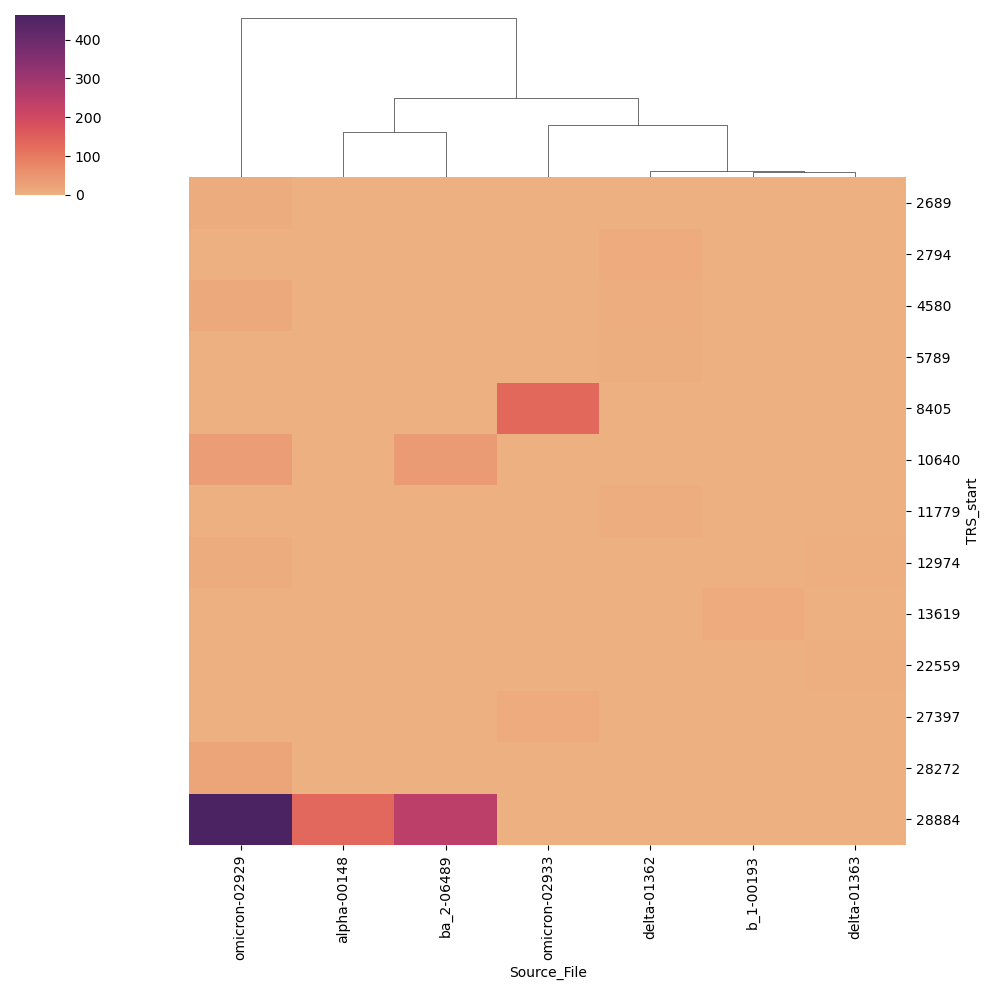

In [32]:
nc_clustermap = nc_leader_strains[~nc_leader_strains["Source_File"].str.contains("SRR|B_1")]

nc_clustermap["TRS_start"] = pd.to_numeric(nc_clustermap["TRS_start"])
nc_clustermap = nc_clustermap.groupby(["Source_File", "TRS_start"], as_index = False).agg(count = ('norm_ct', 'sum')).pivot(columns = "Source_File", index = "TRS_start", values = "count")

#nc_clustermap = nc_clustermap.dropna(axis = 0)
nc_clustermap = nc_clustermap.fillna(0)


sns.clustermap(nc_clustermap, row_cluster = False, cmap = "flare")